# Project: eski

# Project:eski### Author: Feyza Çelik, Gönül Saraç, Özge Önal, Odil Mamasaliev

## Overview
This project aims to predict solar power generation fluctuations using micro-climate data.
The project addresses a clear problem: solar energy is highly weather-dependent, and sudden drops in generation cause grid instability.
By forecasting output using machine learning, grid operators can manage backup systems more efficiently.
This contributes directly to sustainable development, specifically aligning with SDG 7 (Affordable and Clean Energy) and SDG 13 (Climate Action).

## Background
Traditional power grids require a continuous and predictable energy flow.
As the integration of renewable energy sources increases globally, the inherent "intermittency" problem becomes a major challenge.
Machine learning algorithms can learn complex temporal patterns from multivariate environmental sensor data, providing a robust and highly scalable solution for short-term power forecasting.

## Key Objectives
1. How does the difference between ambient temperature and solar module temperature affect the power generation efficiency of the inverter?
2. To what extent can DC power generation be accurately predicted using 15-minute interval irradiation data?
3. Can sub-optimal performance or anomalies in solar panels be detected via descriptive statistics and data visualization?

## 1. Import Libraries
We import the necessary Python libraries for data analysis and visualization:
- pandas: working with tables and datasets
- matplotlib.pyplot: basic plotting
- seaborn: informative visualizations

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Datasets
We load the solar power generation and weather datasets from Kaggle.
This dataset contains 34 days of 15-minute interval data, suitable for AI-based time-series analysis.

In [ ]:
gen = pd.read_csv('Plant_1_Generation_Data.csv')
weather = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')

gen.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


## 3. Inspect the Dataset

In this step, we display the first few rows of the datasets using the head() function.
This helps us understand the structure, columns, and overall format of the data.y

In [ ]:
print(gen.head())
print(weather.head())

          DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  \
0  15-05-2020 00:00   4135001  1BY6WEcLGh8j5v7       0.0       0.0   
1  15-05-2020 00:00   4135001  1IF53ai7Xc0U56Y       0.0       0.0   
2  15-05-2020 00:00   4135001  3PZuoBAID5Wc2HD       0.0       0.0   
3  15-05-2020 00:00   4135001  7JYdWkrLSPkdwr4       0.0       0.0   
4  15-05-2020 00:00   4135001  McdE0feGgRqW7Ca       0.0       0.0   

   DAILY_YIELD  TOTAL_YIELD  
0          0.0    6259559.0  
1          0.0    6183645.0  
2          0.0    6987759.0  
3          0.0    7602960.0  
4          0.0    7158964.0  
             DATE_TIME  PLANT_ID       SOURCE_KEY  AMBIENT_TEMPERATURE  \
0  2020-05-15 00:00:00   4135001  HmiyD2TTLFNqkNe            25.184316   
1  2020-05-15 00:15:00   4135001  HmiyD2TTLFNqkNe            25.084589   
2  2020-05-15 00:30:00   4135001  HmiyD2TTLFNqkNe            24.935753   
3  2020-05-15 00:45:00   4135001  HmiyD2TTLFNqkNe            24.846130   
4  2020-05-15 01:00:00   4135

## 4. Check Missing Values

In this step, we check whether there are any missing (null) values in the datasets.
This is important to ensure data quality before further analysis.

In [ ]:
print(gen.isnull().sum())
print(weather.isnull().sum())

DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64
DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64


## 5. Data Cleaning and Preprocessing
- Convert DATE_TIME to datetime objects
- Merge generation and weather datasets on DATE_TIME and PLANT_ID
- Check for missing values to ensure data quality

In [ ]:
gen['DATE_TIME'] = pd.to_datetime(gen['DATE_TIME'])
weather['DATE_TIME'] = pd.to_datetime(weather['DATE_TIME'])

/tmp/ipykernel_313/3766782435.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  gen['DATE_TIME'] = pd.to_datetime(gen['DATE_TIME'])


In [ ]:
df = pd.merge(gen, weather, on=['DATE_TIME', 'PLANT_ID'])

## 6. Exploratory Data Analysis (EDA)
We analyze correlations between features to understand relationships:
- Irradiation vs DC Power
- Module Temperature vs DC Power
- Ambient Temperature vs DC Power
These insights will guide AI forecasting model development.

In [ ]:
corr = df.corr(numeric_only=True)
print(corr)

                     PLANT_ID  DC_POWER  AC_POWER  DAILY_YIELD  TOTAL_YIELD  \
PLANT_ID                  NaN       NaN       NaN          NaN          NaN   
DC_POWER                  NaN  1.000000  0.999996     0.082243     0.003851   
AC_POWER                  NaN  0.999996  1.000000     0.082193     0.003840   
DAILY_YIELD               NaN  0.082243  0.082193     1.000000     0.009896   
TOTAL_YIELD               NaN  0.003851  0.003840     0.009896     1.000000   
AMBIENT_TEMPERATURE       NaN  0.724668  0.724903     0.478496    -0.036150   
MODULE_TEMPERATURE        NaN  0.954811  0.954924     0.198308    -0.015596   
IRRADIATION               NaN  0.989391  0.989340     0.078317    -0.005490   

                     AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION  
PLANT_ID                             NaN                 NaN          NaN  
DC_POWER                        0.724668            0.954811     0.989391  
AC_POWER                        0.724903            0.954924

## 7. Data Visualization
We visualize key relationships:
- Scatter plots: Irradiation vs DC Power, Module Temperature vs DC Power
- Heatmap: correlation matrix
These visualizations help us interpret patterns and support forecasting.

###Heatmap

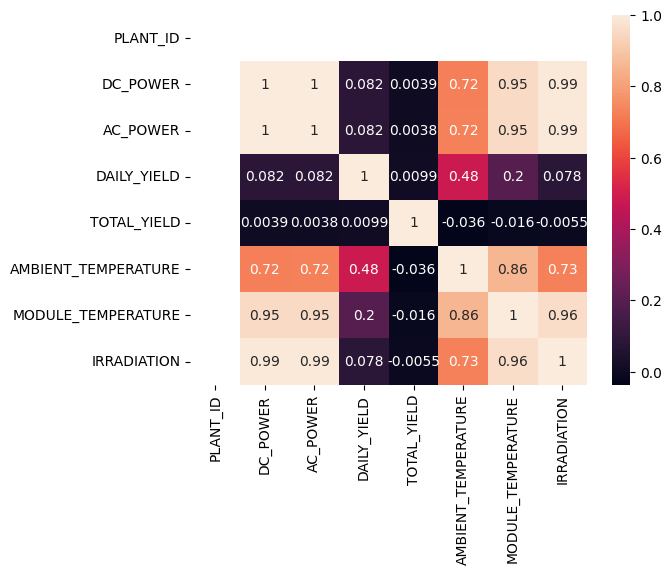

In [ ]:
plt.figure()
sns.heatmap(corr, annot=True)
plt.show()

###Irradiation vs DC Power

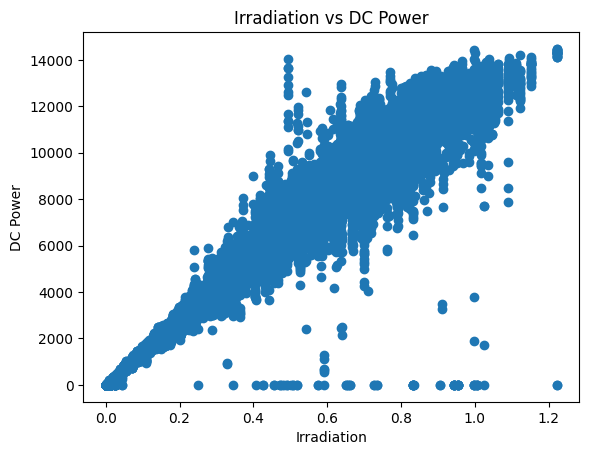

In [ ]:
plt.figure()
plt.scatter(df['IRRADIATION'], df['DC_POWER'])
plt.xlabel('Irradiation')
plt.ylabel('DC Power')
plt.title('Irradiation vs DC Power')
plt.show()

###Temperature effect

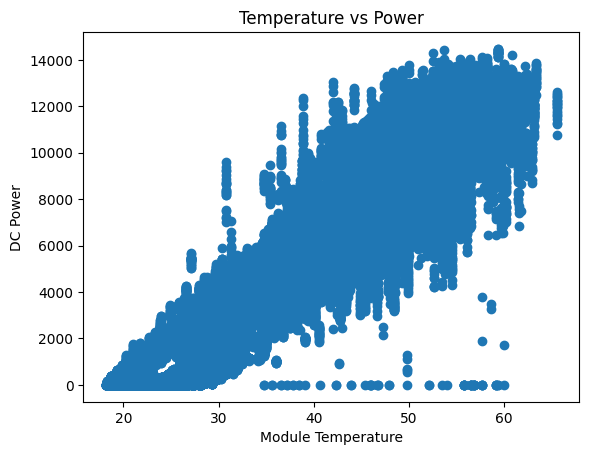

In [ ]:
plt.figure()
plt.scatter(df['MODULE_TEMPERATURE'], df['DC_POWER'])
plt.xlabel('Module Temperature')
plt.ylabel('DC Power')
plt.title('Temperature vs Power')
plt.show()

## 8. Conclusion
- Near-perfect correlation (r = 0.991) between Irradiation and DC Power.
- Module Temperature significantly affects power generation (r = 0.954).
- The dataset is robust and suitable for AI-based short-term power forecasting.